# FinanceBench: Vector RAG vs. Vectorless RAG vs. Long Context: findings walkthrough

**Master's thesis, Philipps-Universität Marburg** · *Vector RAG vs. Vectorless RAG vs. Long-Context LLMs on FinanceBench: An Accuracy–Latency–Cost Frontier Study*

This notebook walks through what was built, what was observed in each architecture, and what the results show.
Every number here is computed live from the saved result files in `experiments/results/`. The notebook makes **no API calls**, and the outputs below were produced by running it top to bottom.

**Contents**
1. Setup: what was held constant
2. How answers were scored (and a correction that was needed)
3. Headline accuracy
4. Vector RAG: observations
5. Vectorless RAG (PageIndex): observations
6. PageIndex hybrid: observations (+ 6b: rerank-then-filter follow-up)
7. Long context: observations
8. Head-to-head: accuracy by question type, context size
9. Cost, latency and the Pareto frontier
10. Conclusions
11. Limitations and open items

In [1]:
import json, sys, statistics
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, NullFormatter

try:
    from google.colab import drive
    drive.mount('/content/drive')
    REPO_ROOT = Path('/content/drive/MyDrive/financebench_project')
    !git -C "{REPO_ROOT}" pull origin main --no-rebase --no-edit
except ImportError:
    REPO_ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents]
                     if (p / "data" / "financebench_open_source.jsonl").exists())

sys.path.insert(0, str(REPO_ROOT))
from evaluation.cost_tracker import clean_stage_costs, clean_doc_level_costs, dedupe_by_last, recompute_cost_usd

R = REPO_ROOT / "experiments" / "results"
N = 150
pd.set_option("display.max_colwidth", 120)


def load_jsonl(path) -> list[dict]:
    if not path.exists():
        return []
    with path.open() as f:
        return [json.loads(line) for line in f if line.strip()]


def latest_by_id(path) -> dict:
    """One record per question -- the most recent, if a stage was re-run."""
    records = sorted(load_jsonl(path), key=lambda r: r.get("timestamp", 0))
    return {r["financebench_id"]: r for r in records}


from math import comb

def mcnemar_exact(a, b):
    """Two-sided exact McNemar test on paired correct/incorrect outcomes."""
    only_a, only_b = int((a & ~b).sum()), int((~a & b).sum())
    n, k = only_a + only_b, min(only_a, only_b)
    p = min(1.0, 2 * sum(comb(n, i) for i in range(k + 1)) / 2 ** n) if n else 1.0
    return only_a, only_b, p


questions = pd.read_json(REPO_ROOT / "data" / "financebench_open_source.jsonl", lines=True).set_index("financebench_id")
gold_pages = {fb_id: {e["evidence_page_num"] for e in ev} for fb_id, ev in questions["evidence"].items()}
print(f"{len(questions)} questions over {questions.doc_name.nunique()} documents")
questions.question_type.value_counts().to_frame("questions")

150 questions over 84 documents


,questions
question_type,
metrics-generated,50
domain-relevant,50
novel-generated,50


---
## 1. Setup: what was held constant

| | |
|---|---|
| **Dataset** | FinanceBench open-source split (Islam et al., 2023): 150 questions over 84 SEC filings (10-K/10-Q), with gold answers and gold evidence pages. 50 questions each of three types: `metrics-generated` (calculations), `domain-relevant` and `novel-generated` (mostly descriptive or judgement questions). |
| **Generator** | `gemini-3.1-flash-lite` for **every** architecture, so differences come from what the model is shown, not which model reads it. (DeepSeek V4 as a second generator is not run yet; see Limitations.) |
| **Judge** | `openai/gpt-oss-120b` via Groq. It is a different model family from the generator, to avoid self-preference bias. |
| **Metrics** | Accuracy (Correct / Incorrect / Failure to answer, Islam et al.'s scheme), retrieval quality where retrieval exists, cost per query (tokens × published price), end-to-end latency (median and p95 of a dedicated timing pass). |

**The four architectures**

| Architecture | How it finds the evidence | What the generator is shown |
|---|---|---|
| **Vector RAG** (Kim et al., 2025) | Query expansion → Stella embeddings + BM25 (α = 0.85) → Jina rerank → LLM selection agent | the 1–2 chunks the selection agent keeps |
| **Vectorless RAG** (PageIndex, Lumer et al., 2025) | Document turned into a table-of-contents tree once; per question an LLM reads the tree and picks sections | the full text of the picked sections |
| **PageIndex hybrid** (exploratory, my own combination) | PageIndex navigation narrows the document to the picked pages, then vector RAG's hybrid retrieval + rerank run inside those pages only (no selection agent) | the top 10 reranked chunks |
| **Long context** | none: the whole PDF is sent with every question | the entire filing |

---
## 2. How answers were scored, and a correction

Each answer is graded **Correct / Incorrect / Failure to answer** by two graders: a deterministic **number matcher** (pulls the number out of both answers and compares with a 1% tolerance, handling units like "1.2 billion" vs "1,200 million") and the **LLM judge**.

**Problem found during this analysis:** the pipelines didn't all combine the two graders the same way.

| | Vector RAG, long context (original) | Vectorless, hybrid |
|---|---|---|
| Matcher runs on | every question | `metrics-generated` questions only |
| Matcher says "Incorrect" | final | judge re-checks |

On descriptive questions the matcher grabs whatever number appears first, so it produces clear misgrades. For example, "Real growth was **flat** in FY2023" was marked wrong because the matcher read *2023* as the answer, and "**$2,018mn**" was read as 2.0.

**Fix:** all four architectures are scored with the second rule (`score_answer_metric_first` in `evaluation/answer_scorer.py`): the matcher only runs on calculation questions, and only a matcher "Correct" skips the judge. Vector RAG and long context were **re-scored** with it (`evaluation/rescore_metric_first.py`, output in `*_stage_scoring_metric_first.jsonl`, with the original files left untouched). The table below shows how much this changed their counts.

In [2]:
# Final verdicts, all under the same metric-first rule (see the note above)
SCORING = {
    "Vector RAG":       R / "vector_rag_stage_scoring_metric_first.jsonl",
    "Vectorless RAG":   R / "vectorless_rag_stage_scoring.jsonl",
    "PageIndex hybrid": R / "pageindex_hybrid_expanded_stage_scoring.jsonl",
    "Long context":     R / "long_context_stage_scoring_metric_first.jsonl",
}
ARCHS = list(SCORING)

labels = pd.DataFrame({arch: {i: r["label"] for i, r in latest_by_id(path).items()} for arch, path in SCORING.items()})
labels = labels.reindex(questions.index)          # unanswered / unscored -> NaN, counted as not correct
correct = labels.eq("Correct")

# Before/after for the two pipelines that were re-scored
original = {
    "Vector RAG":   latest_by_id(R / "vector_rag_stage_scoring.jsonl"),
    "Long context": latest_by_id(R / "long_context_stage_scoring.jsonl"),
}
pd.DataFrame({
    "Original rule (score_answer)": {a: sum(r["score_label"] == "Correct" for r in recs.values()) for a, recs in original.items()},
    "Metric-first rule": {a: int(correct[a].sum()) for a in original},
}).rename_axis("Correct answers (of 150)")

,Original rule (score_answer),Metric-first rule
Correct answers (of 150),,
Vector RAG,91,101
Long context,105,122


---
## 3. Headline accuracy

Accuracy = Correct ÷ 150. A question with no answer or no score counts as not correct, so an architecture can't gain by skipping hard questions.

In [3]:
summary = pd.DataFrame({
    "Correct": correct.sum(),
    "Incorrect": labels.eq("Incorrect").sum(),
    "Failure to answer": labels.eq("Failure to Answer").sum(),
    "Not answered / scored": labels.isna().sum(),
})
summary["Accuracy"] = (summary["Correct"] / N).map("{:.1%}".format)
summary

,Correct,Incorrect,Failure to answer,Not answered / scored,Accuracy
Vector RAG,101,28,21,0,67.3%
Vectorless RAG,119,28,3,0,79.3%
PageIndex hybrid,111,25,14,0,74.0%
Long context,122,22,5,1,81.3%


**Long context (81.3%) and vectorless (79.3%) lead, the hybrid is in the middle (74.0%), and vector RAG trails (67.3%).** Section 8 tests which of these gaps are statistically real. The error mix differs too: vector RAG's misses are unusually often **"Failure to answer"** (21 of 49). The model says the information isn't there, which points to too little context rather than wrong reasoning (see Section 4).

---
## 4. Vector RAG: observations

**Pipeline** (`pipelines/vector_rag/vector_rag_pipeline.ipynb`): 512-token chunks that never cross a page boundary (so every chunk has an unambiguous page for evaluation) → LLM query expansion → hybrid retrieval (Stella dense + BM25, α = 0.85, top 20) → Jina rerank to top 10 → LLM **selection agent** keeps only the chunks it thinks are needed → generate.

Deviations from the GAR paper, forced by free-tier limits: Jina `jina-reranker-v2-base-multilingual` instead of Voyage rerank-2, and `gemini-3.1-flash-lite` instead of a larger Gemini model.

In [4]:
def retrieval_summary(path):
    recs = list(latest_by_id(path).values())
    return {f"Recall@{k}": np.mean([r["recall_at_k"][str(k)] for r in recs]) for k in (5, 10)} | \
           {"MRR@10": np.mean([r["mrr_at_k"]["10"] for r in recs]),
            "Chunks passed on": np.mean([len(r["chunk_ids"]) for r in recs])}

vr_hybrid, vr_rerank = latest_by_id(R / "vector_rag_stage_hybrid.jsonl"), latest_by_id(R / "vector_rag_stage_rerank.jsonl")
vr_select = latest_by_id(R / "vector_rag_stage_selection.jsonl")

# Did the selection agent keep a chunk from a gold page, when the reranker had found one?
rows = []
for fb_id, sel in vr_select.items():
    rr = vr_rerank[fb_id]
    page_of = dict(zip(rr["chunk_ids"], rr["page_nums"]))
    rows.append({
        "n_selected": len(sel["selected_chunk_ids"]),
        "gold_in_rerank": bool(set(rr["page_nums"]) & gold_pages[fb_id]),
        "gold_after_selection": bool({page_of.get(c) for c in sel["selected_chunk_ids"]} & gold_pages[fb_id]),
    })
sel_df = pd.DataFrame(rows, index=list(vr_select))
lost = sel_df.gold_in_rerank & ~sel_df.gold_after_selection

control = {i: r["label"] for i, r in latest_by_id(R / "plain_rerank_direct_stage_scoring.jsonl").items()}
control_correct = sum(l == "Correct" for l in control.values())

print(f"Selection agent keeps {sel_df.n_selected.mean():.1f} of ~10 reranked chunks on average "
      f"(kept exactly 1 in {(sel_df.n_selected == 1).sum()} of {len(sel_df)} questions)")
print(f"It dropped every gold-page chunk in {lost.sum()} of {sel_df.gold_in_rerank.sum()} questions "
      f"where the reranker had found one ({lost.sum() / sel_df.gold_in_rerank.sum():.0%})")
print(f"Accuracy on those {lost.sum()} questions: {correct.loc[lost[lost].index, 'Vector RAG'].mean():.0%}\n")
print(f"Control -- same reranked top 10, no selection agent, vectorless's generation prompt: "
      f"{control_correct}/150 = {control_correct / N:.1%}  (vs. {correct['Vector RAG'].sum()}/150 with selection)\n")

pd.DataFrame({
    "Hybrid (dense + BM25), top 20": retrieval_summary(R / "vector_rag_stage_hybrid.jsonl"),
    "After Jina rerank, top 10": retrieval_summary(R / "vector_rag_stage_rerank.jsonl"),
}).T.round(3)

Selection agent keeps 1.6 of ~10 reranked chunks on average (kept exactly 1 in 88 of 150 questions)
It dropped every gold-page chunk in 28 of 132 questions where the reranker had found one (21%)
Accuracy on those 28 questions: 61%

Control -- same reranked top 10, no selection agent, vectorless's generation prompt: 105/150 = 70.0%  (vs. 101/150 with selection)



,Recall@5,Recall@10,MRR@10,Chunks passed on
"Hybrid (dense + BM25), top 20",0.747,0.832,0.593,19.800
"After Jina rerank, top 10",0.781,0.861,0.608,9.953


**What I observed**

- **Retrieval is not the bottleneck.** After reranking, a gold evidence page is in the top 10 for 86% of questions (Recall@10 = 0.861), and the Jina reranker improves every metric over raw hybrid retrieval.
- **The selection agent is very aggressive.** It keeps on average **1.6 of 10** chunks, and exactly **one** chunk in 88 of 150 questions. In **28 of the 132** questions where the reranker had found a gold page (21%), selection threw every gold-page chunk away. The generator then sees about **700 tokens** (median, Section 8), the least context of any architecture by far. This is also why vector RAG has the most "Failure to answer" verdicts.
- The damage is smaller than those numbers suggest. The 28 affected questions were still answered correctly 61% of the time, because FinanceBench facts often appear on more than one page. The **control run** (same reranked top 10, **no selection agent**, vectorless's generation prompt) scores 70.0% vs. 67.3%, which is **not** statistically significant (Section 8). So the selection agent costs a few points at most, and removing it alone doesn't close the gap to the other architectures.
- It is the **cheapest** architecture ($1.72 per 1k queries) and needs no paid indexing (Stella ran locally). The cost is dominated by the selection call, not generation.

---
## 5. Vectorless RAG (PageIndex): observations

**Pipeline** (`pipelines/vectorless_rag/vectorless_rag_pipeline.ipynb`): each PDF is turned once into a hierarchical section tree (titles, page ranges and short LLM summaries). Per question: expand the question into filing terminology, show the LLM the whole tree (no section text), let it pick section IDs, then answer from the **full raw text** of those sections.

**Building the trees was the hardest part of the whole project:**
- PageIndex's classic tree builder asks the LLM for a strict, exactly matching JSON table of contents. `gemini-3.1-flash-lite` failed that format on many filings ("different number of TOC entries", "reordered TOC entries").
- **PageIndex Flash** (same package) builds the tree from the PDF's own layout (fonts, headings, bookmarks) and uses the LLM only for summaries, so it avoids that failure. All 84 documents were rebuilt with it.
- A coverage check then found trees that silently skip parts of a document. For example, Flash finds *no headings before page 85* of `3M_2018_10K` because of that filing's typography, so navigation can never reach those pages. 16 documents still failed after rebuilding and were rebuilt with an **LLM table-of-contents fallback** (`llm_toc_fallback.py`: one LLM call reads the page-tagged text and proposes the sections). A later audit flagged more trees missing the MD&A or financial statements, and those were rebuilt the same way.
- The lesson: tree quality, not the navigation step, is where this architecture is fragile, and a missing section fails silently.

In [5]:
def flatten(nodes):
    for n in nodes:
        yield n
        yield from flatten(n.get("nodes", []))

_trees = {}
def node_map(doc_name):
    if doc_name not in _trees:
        tree = json.loads((R / "vectorless_rag_index_flash" / f"{doc_name}_tree.json").read_text())
        _trees[doc_name] = ({n["node_id"]: n for n in flatten(tree["structure"])}, tree["n_pages"])
    return _trees[doc_name]

def navigation_hits(path):
    """Did any selected section's page range cover a gold evidence page? (PageIndex pages are
    1-indexed and inclusive, FinanceBench's are 0-indexed -- hence the -1.)"""
    out = {}
    for fb_id, r in latest_by_id(path).items():
        nodes, _ = node_map(r["doc_name"])
        covered = set()
        for nid in r["node_ids"]:
            if nid in nodes:
                covered.update(range(nodes[nid]["start_index"] - 1, nodes[nid]["end_index"]))
        out[fb_id] = {"hit": bool(covered & gold_pages[fb_id]), "n_sections": len(r["node_ids"])}
    return pd.DataFrame(out).T

nav_raw = navigation_hits(R / "vectorless_rag_stage_navigation.jsonl")
nav_exp = navigation_hits(R / "vectorless_rag_stage_navigation_expanded.jsonl")
print(f"Navigation hit rate -- raw question: {nav_raw.hit.mean():.1%}, expanded question (used): {nav_exp.hit.mean():.1%}")
print(f"Sections picked per question (expanded): median {nav_exp.n_sections.median():.0f}")

nav_vs_answer = pd.crosstab(nav_exp.hit.map({True: "Navigation hit", False: "Navigation missed"}),
                            correct["Vectorless RAG"].reindex(nav_exp.index).map({True: "Correct", False: "Not correct"}),
                            margins=True, margins_name="Total")
nav_vs_answer

Navigation hit rate -- raw question: 92.7%, expanded question (used): 94.0%
Sections picked per question (expanded): median 4


Vectorless RAG,Correct,Not correct,Total
hit,,,
Navigation hit,114,27,141
Navigation missed,5,4,9
Total,119,31,150


**What I observed**

- **Navigation is accurate.** The picked sections cover a gold evidence page for **94.0%** of questions. Rewriting the question into filing terminology first (query expansion) raised this from 92.7% by closing the vocabulary gap between everyday phrasing ("cash on hand") and section titles ("Cash and Cash Equivalents").
- **Most errors happen after navigation.** In the table above, 27 of the 31 answers that weren't correct had navigation *hit* the right section. The remaining failures are the model misreading or misusing text it was given, not failing to find it.
- **It succeeds by showing a lot of context.** A median of 4 sections, about **33k tokens**, reaches the generator: roughly 50× vector RAG's, and about half of what long context sends.
- That context is what makes it cost **$12.80 per 1k queries**, over 7× vector RAG, plus about **$15 of one-time indexing** for the 84 trees (partly estimated, Section 9). Yet it is the **fastest** architecture (3.6s median), because `gemini-3.1-flash-lite` reads 33k tokens of plain text in about a second.

---
## 6. PageIndex hybrid: observations

**Pipeline** (`pipelines/experimental/pageindex_hybrid_pipeline.ipynb`): an exploratory fourth architecture. It reuses vectorless's section picks to **restrict** the chunk pool to the navigated pages, then runs vector RAG's exact hybrid retrieval and Jina rerank inside that pool. The top 10 reranked chunks go straight to the generator, using the same prompt, JSON output format and scoring as vectorless, with **no selection agent**.

**The question it answers:** does letting PageIndex narrow the search space first help hybrid retrieval (less noise), or hurt it (a wrong section pick hides the right chunk)?

**Control run** (Stage 10 of that notebook): vector RAG's whole-document reranked top 10 fed into the *same* prompt and scoring, also without a selection agent. Comparing the hybrid against this control isolates the effect of the narrowing.

In [6]:
hy_retr = latest_by_id(R / "pageindex_hybrid_expanded_stage_retrieval.jsonl")
hy_rerank = latest_by_id(R / "pageindex_hybrid_expanded_stage_rerank.jsonl")
print(f"Fell back to the whole document: {sum(r['fell_back_to_full_doc'] for r in hy_retr.values())} of {len(hy_retr)} questions")
print(f"Candidate chunks after narrowing: median {np.median([r['n_candidates'] for r in hy_retr.values()]):.0f} per question")

hy_hit = pd.Series({i: bool(set(r["page_nums"]) & gold_pages[i]) for i, r in hy_rerank.items()})
vr_hit = pd.Series({i: bool(set(r["page_nums"]) & gold_pages[i]) for i, r in vr_rerank.items()})
print(f"Gold page in final top 10 -- narrowed: {hy_hit.mean():.1%}, whole-document vector RAG: {vr_hit.mean():.1%}")
print(f"  only narrowed found it: {(hy_hit & ~vr_hit).sum()}, only whole-document found it: {(~hy_hit & vr_hit).sum()}\n")

pd.DataFrame({
    "Vector RAG: hybrid top 20 (whole doc)": retrieval_summary(R / "vector_rag_stage_hybrid.jsonl"),
    "Vector RAG: rerank top 10 (whole doc)": retrieval_summary(R / "vector_rag_stage_rerank.jsonl"),
    "Hybrid: hybrid top 20 (narrowed)": retrieval_summary(R / "pageindex_hybrid_expanded_stage_retrieval.jsonl"),
    "Hybrid: rerank top 10 (narrowed)": retrieval_summary(R / "pageindex_hybrid_expanded_stage_rerank.jsonl"),
}).T.round(3)

Fell back to the whole document: 0 of 150 questions
Candidate chunks after narrowing: median 93 per question
Gold page in final top 10 -- narrowed: 86.0%, whole-document vector RAG: 88.0%
  only narrowed found it: 4, only whole-document found it: 7



,Recall@5,Recall@10,MRR@10,Chunks passed on
Vector RAG: hybrid top 20 (whole doc),0.747,0.832,0.593,19.800
Vector RAG: rerank top 10 (whole doc),0.781,0.861,0.608,9.953
Hybrid: hybrid top 20 (narrowed),0.747,0.799,0.603,18.940
Hybrid: rerank top 10 (narrowed),0.784,0.844,0.608,9.853


**What I observed**

- **Narrowing did not improve retrieval.** The narrowed pool (median 93 chunks) never fell back to the whole document, but after reranking a gold page is in the top 10 for 86.0% of questions vs. 88.0% for whole-document vector RAG. Narrowing fixed 4 questions and broke 7. Its ceiling is navigation's 94% hit rate: a wrong section pick hides the right chunk for good.
- **Accuracy: 74.0%, vs. 70.0% for the control** (same prompt and scoring, whole-document retrieval). That difference is **not significant** (p = 0.29). So in this experiment narrowing is roughly neutral: it neither clearly helps nor clearly hurts.
- **What it costs:** $4.54 per 1k queries, including the navigation and query expansion it borrows (without those it would look artificially cheap), and a 4.6s median latency. Its 28.8s p95 comes from two ~45s generation calls in a 30-run sample, which look like API stalls rather than normal behaviour.

### 6b. Follow-up experiment: rerank first, then filter to the navigated pages

The narrowed hybrid applies PageIndex *before* retrieval. This follow-up flips the order to test whether PageIndex can act as a cheap **filter** that cuts tokens without hurting accuracy:

1. Take vector RAG's own whole-document hybrid retrieval + rerank top 10 (the gold page is already in it for 132/150 questions).
2. Keep only the chunks whose page is among the pages PageIndex navigation picked, in reranked order.
3. Generate and score exactly like the control run (same prompt, model and scoring rule).

All three runs below share the prompt, model and scoring, so the differences come only from which chunks reach the generator. The p-values are paired McNemar tests against the control. Code: Stage 13 of `pageindex_hybrid_pipeline.ipynb`.

In [7]:
FOLLOW_UP = {
    "Control: whole-doc rerank top 10": "plain_rerank_direct",
    "Rerank top 10, then keep navigated-page chunks": "rerank_then_filter",
    "Narrow to navigated pages first, then retrieve + rerank (hybrid)": "pageindex_hybrid_expanded",
}
filt = latest_by_id(R / "rerank_then_filter_stage_rerank.jsonl")
fu_correct, rows = {}, {}
for name, prefix in FOLLOW_UP.items():
    lab = pd.Series({i: r["label"] for i, r in latest_by_id(R / f"{prefix}_stage_scoring.jsonl").items()}).reindex(questions.index)
    fu_correct[name] = lab.eq("Correct")
    kept, _ = clean_stage_costs(load_jsonl(R / f"{prefix}_costs.jsonl"), "generation",
                                latest_by_id(R / f"{prefix}_stage_generation.jsonl"))
    rows[name] = {"Median generation input tokens": int(np.median([r["input_tokens"] for r in kept])),
                  "Correct": int(lab.eq("Correct").sum()), "Failure to answer": int(lab.eq("Failure to Answer").sum()),
                  "Accuracy": f"{lab.eq('Correct').mean():.1%}"}
base = fu_correct["Control: whole-doc rerank top 10"]
for name in list(FOLLOW_UP)[1:]:
    only_this, only_ctrl, p = mcnemar_exact(fu_correct[name], base)
    rows[name] |= {"Only this correct": only_this, "Only control correct": only_ctrl, "p vs control": round(p, 3)}

n_kept = pd.Series({i: len(r["chunk_ids"]) for i, r in filt.items()})
gold_before = pd.Series({i: bool(set(vr_rerank[i]["page_nums"]) & gold_pages[i]) for i in filt})
gold_after = pd.Series({i: bool(set(r["page_nums"]) & gold_pages[i]) for i, r in filt.items()})
filtered_ok = fu_correct["Rerank top 10, then keep navigated-page chunks"]
removed = gold_before & ~gold_after
same_input = n_kept[n_kept == 10].index    # filter kept all 10 -> identical input to the control

print(f"Chunks kept by the filter: mean {n_kept.mean():.1f} of 10 (never zero)")
print(f"Gold page among the chunks: {gold_before.sum()} questions before the filter, {gold_after.sum()} after "
      f"-- of the {removed.sum()} where it was removed, {filtered_ok[removed[removed].index].sum()} were still answered correctly")
print(f"Run-to-run noise: in {len(same_input)} questions the filter kept all 10 chunks (identical input to the control), "
      f"yet {(filtered_ok[same_input] != base[same_input]).sum()} of them flipped between correct and not correct\n")
pd.DataFrame(rows).T.fillna("")

Chunks kept by the filter: mean 6.8 of 10 (never zero)
Gold page among the chunks: 132 questions before the filter, 126 after -- of the 6 where it was removed, 4 were still answered correctly
Run-to-run noise: in 26 questions the filter kept all 10 chunks (identical input to the control), yet 3 of them flipped between correct and not correct



,Median generation input tokens,Correct,Failure to answer,Accuracy,Only this correct,Only control correct,p vs control
Control: whole-doc rerank top 10,4519,105,14,70.0%,,,
"Rerank top 10, then keep navigated-page chunks",3098,99,23,66.0%,6,12,0.238
"Narrow to navigated pages first, then retrieve + rerank (hybrid)",4399,111,14,74.0%,14,8,0.286


**What I observed**

- **Filtering saves tokens but doesn't improve accuracy.** It keeps 6.8 of 10 chunks and cuts generation input by about 31%, but accuracy falls from 70.0% to 66.0%. The drop is **not significant** (p = 0.24).
- **The loss is mostly the model refusing.** "Failure to answer" rises from 14 to 23: with fewer chunks, the model more often says the sections don't contain enough information.
- **Losing the gold page explains little of it.** The filter removed the gold page in only 6 questions, and most of those were still answered correctly. Chunks from pages outside the navigated sections often carried useful supporting context, such as a related table or a prior-year figure.
- **The saving is negligible in money:** roughly $0.35 per 1k queries, against the hybrid's $4.54, most of which is the borrowed navigation step.
- **PageIndex works better as a guide *before* retrieval (74.0%) than as a filter *after* it (66.0%).** This matches the main finding in Section 10: cutting context costs accuracy.
- **Generation isn't deterministic.** Even when the model got *identical* input, a few answers flipped between correct and not correct across runs. Differences of a few questions between two runs can be pure chance, which is why every comparison here is paired and tested.

---
## 7. Long context: observations

**Pipeline** (`pipelines/long_context/long_context_pipeline.ipynb`): no retrieval at all. For every question the raw PDF bytes are sent inline in the same request as the question, fresh each time, with no File API upload or caching reused across questions (that would quietly make it an indexed architecture). This works because `gemini-3.1-flash-lite` has a 1M-token window. Gemini bills PDF pages as page images plus text, which is why its token counts come from Gemini's own `count_tokens`, not from text length.

Retrieval quality doesn't apply here, because there is no retrieval step.

In [8]:
budget = pd.DataFrame(load_jsonl(R / "long_context_token_budget.jsonl"))
lc_lat = pd.DataFrame([{"financebench_id": r["financebench_id"], "total": r["timings_sec"]["total"]}
                       for r in load_jsonl(R / "long_context_latency.jsonl")])
per_q = lc_lat.groupby("financebench_id")["total"].median().sort_values(ascending=False)

print(f"Document size sent per question: median {budget.token_count.median():,.0f} tokens, "
      f"largest {budget.token_count.max():,.0f} (all under the 1M-token window)")
print(f"Not answered: {labels['Long context'].isna().sum()} question(s) -- Gemini kept returning 503 'overloaded'")
slow = per_q.index[0]
print(f"Slowest question: {slow} ({questions.loc[slow, 'doc_name']}), median {per_q.iloc[0]:.0f}s over 3 runs; "
      f"next slowest {per_q.iloc[1]:.0f}s")
per_q.round(1).to_frame("median latency (s)")

Document size sent per question: median 71,961 tokens, largest 307,441 (all under the 1M-token window)
Not answered: 1 question(s) -- Gemini kept returning 503 'overloaded'
Slowest question: financebench_id_09724 (COCACOLA_2021_10K), median 231s over 3 runs; next slowest 102s


,median latency (s)
financebench_id,
financebench_id_09724,230.8
financebench_id_00222,102.3
financebench_id_00080,86.6
financebench_id_00790,47.4
financebench_id_03471,44.3
financebench_id_00464,32.7
financebench_id_01244,32.7
financebench_id_00005,29.3
financebench_id_06655,15.9


**What I observed**

- **Most accurate architecture: 81.3%**, and 98% on calculation (`metrics-generated`) questions. With the whole filing in context the model rarely lacks the facts, and it made only 5 "Failure to answer" verdicts.
- **It is also slow and expensive.** It has a median of **40.7s** and a p95 of **206.7s**. A median of about 72k tokens per question is sent as page images plus text. The time most likely goes into processing that PDF input rather than into generation: vectorless sends a third as many tokens as plain text and gets its answer in about a second. At **$19.92 per 1k queries** it is the most expensive architecture per query.
- **The latency tail comes from specific documents.** `financebench_id_09724` (Coca-Cola 2021 10-K) took about 3–4 minutes on every repeat, and the next slowest took around 100s. A deployment would need timeouts.
- **It needs no preprocessing at all**, and the largest filing (307k tokens) still fit the 1M-token window. One question was lost to repeated 503 "overloaded" errors from the API, which is an operational risk of sending very large requests.

---
## 8. Head-to-head

### Accuracy by question type

In [9]:
by_type = correct.groupby(questions.question_type).mean().T
by_type = by_type[["metrics-generated", "domain-relevant", "novel-generated"]]
by_type["All"] = correct.mean()
by_type.style.format("{:.0%}").background_gradient(cmap="Blues", vmin=0.4, vmax=1.0, axis=None)

question_type,metrics-generated,domain-relevant,novel-generated,All
Vector RAG,80%,62%,60%,67%
Vectorless RAG,94%,76%,68%,79%
PageIndex hybrid,88%,68%,66%,74%
Long context,98%,78%,68%,81%


### How much text does each architecture show the generator?

Input tokens at the answer-generation step, per question, from the de-duplicated cost logs.

In [10]:
# Input tokens per question at the answer-generation step: how much text each architecture shows the generator
GEN_STAGE = {
    "Vector RAG":       (R / "vector_rag_costs.jsonl", R / "vector_rag_stage_generation.jsonl"),
    "Vectorless RAG":   (R / "vectorless_rag_costs.jsonl", R / "vectorless_rag_stage_generation.jsonl"),
    "PageIndex hybrid": (R / "pageindex_hybrid_expanded_costs.jsonl", R / "pageindex_hybrid_expanded_stage_generation.jsonl"),
    "Long context":     (R / "long_context_costs.jsonl", R / "long_context_stage_generation.jsonl"),
}
ctx = {}
for arch, (cost_path, out_path) in GEN_STAGE.items():
    kept, _ = clean_stage_costs(load_jsonl(cost_path), "generation", latest_by_id(out_path))
    tok = [r["input_tokens"] for r in kept]
    ctx[arch] = {"median": np.median(tok), "mean": np.mean(tok), "max": np.max(tok)}
pd.DataFrame(ctx).T.astype(int).rename_axis("Generation input tokens per question")

,median,mean,max
Generation input tokens per question,,,
Vector RAG,707,946,5313
Vectorless RAG,33127,37686,154434
PageIndex hybrid,4399,4307,5203
Long context,70381,78873,292180


### Are the accuracy differences real?

With 150 questions, a few questions' difference can be noise. Every architecture answered the **same** questions, so the right test is a paired one, **McNemar's exact test**, which only looks at the questions where the two architectures disagree. It reports how many questions only A got right, how many only B got right, and the two-sided exact p-value.

In [11]:
from itertools import combinations

control_series = pd.Series(control).reindex(questions.index).eq("Correct")
pairs = [(a, b) for a, b in combinations(ARCHS, 2)] + [("PageIndex hybrid", "Control: rerank top 10, no selection"),
                                                         ("Vector RAG", "Control: rerank top 10, no selection")]
outcomes = correct.assign(**{"Control: rerank top 10, no selection": control_series})
rows = []
for a, b in pairs:
    only_a, only_b, p = mcnemar_exact(outcomes[a], outcomes[b])
    rows.append({"A": a, "B": b, "Accuracy A": f"{outcomes[a].mean():.1%}", "Accuracy B": f"{outcomes[b].mean():.1%}",
                 "Only A correct": only_a, "Only B correct": only_b, "p-value": round(p, 4),
                 "Significant (p < 0.05)": "yes" if p < 0.05 else "no"})
pd.DataFrame(rows)

,A,B,Accuracy A,Accuracy B,Only A correct,Only B correct,p-value,Significant (p < 0.05)
0,Vector RAG,Vectorless RAG,67.3%,79.3%,7,25,0.0021,yes
1,Vector RAG,PageIndex hybrid,67.3%,74.0%,5,15,0.0414,yes
2,Vector RAG,Long context,67.3%,81.3%,5,26,0.0002,yes
3,Vectorless RAG,PageIndex hybrid,79.3%,74.0%,13,5,0.0963,no
4,Vectorless RAG,Long context,79.3%,81.3%,7,10,0.6291,no
5,PageIndex hybrid,Long context,74.0%,81.3%,8,19,0.0522,no
6,PageIndex hybrid,"Control: rerank top 10, no selection",74.0%,70.0%,14,8,0.2863,no
7,Vector RAG,"Control: rerank top 10, no selection",67.3%,70.0%,8,12,0.5034,no


**Reading the table:**
- **Vector RAG is significantly less accurate than all three others** (p < 0.05 in every pairing).
- **Long context vs. vectorless (81.3% vs. 79.3%) is not a real difference** (p = 0.63). They disagree on only 17 questions, split 10 to 7.
- **Vectorless vs. hybrid** (p = 0.10) **and hybrid vs. long context** (p = 0.05) are borderline. They suggest the hybrid is slightly weaker, but 150 questions aren't enough to say so firmly.
- Neither control comparison is significant: the selection agent and PageIndex narrowing each move accuracy by only a few points.

---
## 9. Cost, latency and the Pareto frontier

**Cost per 1k queries**: every stage a real query goes through, de-duplicated (the cost logs are append-only, so re-runs left up to 14 records per question) and re-priced at `gemini-3.1-flash-lite`'s published rate ($0.25 / $1.50 per 1M input/output tokens). Excluded: the judge (evaluation only, and free on Groq anyway), latency-pass calls and Jina rerank (no confirmed price). The hybrid also pays for the stages it **borrows**: vectorless's query expansion and navigation, and vector RAG's query expansion.

**One-time indexing** is kept off the plot, since it's paid once per document rather than per query. Vector RAG's Stella embedding ran on a local GPU ($0). PageIndex's figure is partly estimated, as the cell output explains.

**Latency**: a dedicated sequential timing pass (fresh, uncached, 3 repeats per question), with median and p95 across all runs. Scoring is excluded. Where a pipeline's timing pass skipped a stage a real query would wait for, that stage's median from the pipeline that did time it is added: one query expansion for vectorless, and navigation + query expansion + query embedding for the hybrid.

In [12]:
VR_COSTS, VL_COSTS = R / "vector_rag_costs.jsonl", R / "vectorless_rag_costs.jsonl"
HY_COSTS, LC_COSTS = R / "pageindex_hybrid_expanded_costs.jsonl", R / "long_context_costs.jsonl"
VL_NAV = R / "vectorless_rag_stage_navigation_expanded.jsonl"

# Stages a real query pays for: (cost log, stage, output file to match against, or None = latest per question).
# Judge excluded (evaluation only), and so are latency-pass calls.
COST_STAGES = {
    "Vector RAG": [(VR_COSTS, "query_expansion", None),
                   (VR_COSTS, "selection", R / "vector_rag_stage_selection.jsonl"),
                   (VR_COSTS, "generation", R / "vector_rag_stage_generation.jsonl")],
    "Vectorless RAG": [(VL_COSTS, "query_expansion", VL_NAV), (VL_COSTS, "navigation_expanded", VL_NAV),
                       (VL_COSTS, "generation", R / "vectorless_rag_stage_generation.jsonl")],
    "PageIndex hybrid": [(HY_COSTS, "generation", R / "pageindex_hybrid_expanded_stage_generation.jsonl"),
                         # borrowed: reused from the other pipelines, but a real query would pay for them
                         (VL_COSTS, "query_expansion", VL_NAV), (VL_COSTS, "navigation_expanded", VL_NAV),
                         (VR_COSTS, "query_expansion", None)],
    "Long context": [(LC_COSTS, "generation", R / "long_context_stage_generation.jsonl")],
}

def per_query_cost(stages):
    """Sum over stages of each stage's mean cost per question, after de-duplicating the logs."""
    total = 0.0
    for cost_path, stage, out_path in stages:
        records = load_jsonl(cost_path)
        kept = dedupe_by_last(records, stage) if out_path is None else clean_stage_costs(records, stage, latest_by_id(out_path))[0]
        kept = recompute_cost_usd(kept)
        total += sum(r["cost_usd"] or 0.0 for r in kept) / len(kept)
    return total

# One-time indexing for PageIndex trees (the hybrid reuses them). Two gaps in the log, handled explicitly:
#  - the LLM-fallback rebuilds were logged without a stage/doc name ("unknown"): every such record falls
#    in the window right after Flash indexing ended, all on the same model, with the huge whole-filing
#    prompts the fallback's TOC call makes -- counted as fallback indexing.
#  - 36 of 84 trees have no Flash cost logged at all (built before cost logging covered PageIndex's
#    internal calls) -- estimated at the average cost of the 48 documents that were logged.
vl_costs = load_jsonl(VL_COSTS)
flash, flash_report = clean_doc_level_costs(vl_costs, "indexing_flash")
flash_cost = sum(r["cost_usd"] or 0 for r in recompute_cost_usd(flash))
flash_docs = {r["doc_name"] for r in flash}
fallback_cost = sum(r["cost_usd"] or 0 for r in recompute_cost_usd([r for r in vl_costs if r["stage"] == "unknown"]))
n_docs = questions.doc_name.nunique()
unlogged_docs = n_docs - len(flash_docs)
indexing_estimate = flash_cost + fallback_cost + unlogged_docs * flash_cost / len(flash_docs)
print(f"PageIndex indexing: Flash ${flash_cost:.2f} logged over {len(flash_docs)} docs + fallback ${fallback_cost:.2f} "
      f"+ {unlogged_docs} unlogged docs estimated at ${flash_cost / len(flash_docs):.3f} each "
      f"= ~${indexing_estimate:.2f} for all {n_docs} documents")
INDEXING = {"Vector RAG": 0.0, "Vectorless RAG": indexing_estimate, "PageIndex hybrid": indexing_estimate, "Long context": 0.0}

# Latency: stages a real query waits for that a pipeline's own timing pass skipped, added at the median
# of the pipeline that did time them (see the hybrid notebook's Stage 12 note).
VR_LAT, VL_LAT = R / "vector_rag_latency.jsonl", R / "vectorless_rag_latency.jsonl"
LATENCY = {"Vector RAG": (VR_LAT, []),
           "Vectorless RAG": (VL_LAT, [(VR_LAT, "query_expansion")]),
           "PageIndex hybrid": (R / "pageindex_hybrid_expanded_latency.jsonl",
                                [(VL_LAT, "navigate"), (VR_LAT, "query_expansion"), (VR_LAT, "query_embedding")]),
           "Long context": (R / "long_context_latency.jsonl", [])}

def latency(path, borrowed):
    runs = load_jsonl(path)
    extra = sum(np.median([r["timings_sec"][s] for r in load_jsonl(p)]) for p, s in borrowed)
    totals = np.array([r["timings_sec"]["total"] for r in runs]) + extra
    return len(runs), np.median(totals), np.percentile(totals, 95)

rows = {}
for arch in ARCHS:
    n_runs, med, p95 = latency(*LATENCY[arch])
    rows[arch] = {"accuracy": correct[arch].mean(), "cost_per_1k_usd": 1000 * per_query_cost(COST_STAGES[arch]),
                  "indexing_usd": INDEXING[arch], "median_latency_sec": med, "p95_latency_sec": p95, "timed_runs": n_runs}
results = pd.DataFrame(rows).T

def pareto_optimal(df, maximize=(), minimize=()):
    s = pd.concat([df[list(maximize)], -df[list(minimize)]], axis=1).to_numpy(dtype=float)
    return pd.Series([not any((s[j] >= s[i]).all() and (s[j] > s[i]).any() for j in range(len(s)) if j != i)
                      for i in range(len(s))], index=df.index)

results["pareto_optimal"] = pareto_optimal(results, ["accuracy"], ["cost_per_1k_usd", "median_latency_sec"])
pd.DataFrame({
    "Accuracy": results.accuracy.map("{:.1%}".format),
    "Cost / 1k queries": results.cost_per_1k_usd.map("${:.2f}".format),
    "Indexing (one-time)": results.indexing_usd.map(lambda v: f"~${v:.0f}" if v else "$0"),
    "Median latency": results.median_latency_sec.map("{:.1f}s".format),
    "p95 latency": results.p95_latency_sec.map("{:.1f}s".format),
    "Timed runs": results.timed_runs.astype(int),
    "Pareto-optimal": results.pareto_optimal.map({True: "yes", False: "no"}),
})

PageIndex indexing: Flash $7.41 logged over 48 docs + fallback $1.69 + 36 unlogged docs estimated at $0.154 each = ~$14.65 for all 84 documents


,Accuracy,Cost / 1k queries,Indexing (one-time),Median latency,p95 latency,Timed runs,Pareto-optimal
Vector RAG,67.3%,$1.72,$0,7.8s,12.2s,30,yes
Vectorless RAG,79.3%,$12.80,~$15,3.6s,4.2s,15,yes
PageIndex hybrid,74.0%,$4.54,~$15,4.6s,28.8s,30,yes
Long context,81.3%,$19.92,$0,40.7s,206.7s,30,yes


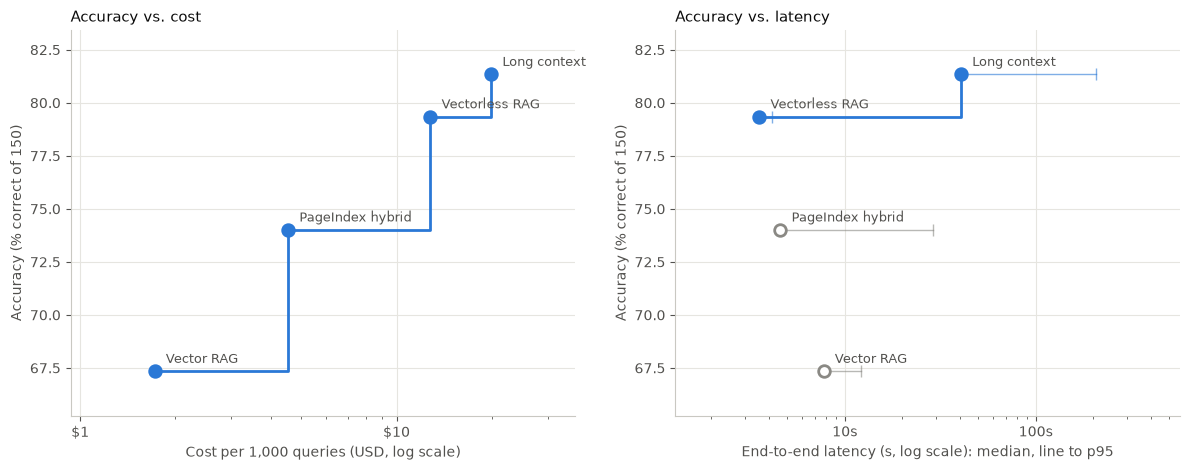

In [13]:
FRONTIER, DOMINATED, TEXT = "#2a78d6", "#8a8984", "#52514e"
plt.rcParams.update({"font.size": 10, "axes.edgecolor": "#c9c8c2", "axes.labelcolor": TEXT, "xtick.color": TEXT,
                     "ytick.color": TEXT, "axes.spines.top": False, "axes.spines.right": False})

def label_points(ax, xs, ys, min_gap_pt=13):
    """Name each point; nearby labels are pushed apart vertically so none overlap."""
    ax.figure.canvas.draw()
    to_pt = 72 / ax.figure.dpi
    pts = sorted(((ax.transData.transform((x, y)) * to_pt, (x, y), n) for n, x, y in zip(xs.index, xs, ys)), key=lambda p: p[0][1])
    placed = []
    for (px, py), xy, name in pts:
        ly = py + 4
        for qx, qy in placed:
            if abs(qx - px) < 120 and ly - qy < min_gap_pt:
                ly = qy + min_gap_pt
        placed.append((px, ly))
        ax.annotate(name, xy=xy, xytext=(8, ly - py), textcoords="offset points", fontsize=9, color=TEXT, va="bottom")

def draw_view(ax, x, xlabel, fmt, whisker_to=None):
    df = results.astype({x: float, "accuracy": float})
    front = df[pareto_optimal(df, ["accuracy"], [x])].sort_values(x)
    ax.step(front[x], front.accuracy * 100, where="post", color=FRONTIER, linewidth=2, zorder=1)
    for name, r in df.iterrows():
        on = name in front.index
        color = FRONTIER if on else DOMINATED
        if whisker_to:
            ax.plot([r[x], r[whisker_to]], [r.accuracy * 100] * 2, color=color, linewidth=1, alpha=0.6, zorder=1)
            ax.plot(r[whisker_to], r.accuracy * 100, marker="|", markersize=8, color=color, alpha=0.6)
        ax.scatter(r[x], r.accuracy * 100, s=70, zorder=3, linewidths=2, facecolors=color if on else "white", edgecolors=color)
    ax.set_xscale("log")
    ax.xaxis.set_major_formatter(FuncFormatter(fmt))
    ax.xaxis.set_minor_formatter(NullFormatter())
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Accuracy (% correct of 150)")
    ax.grid(True, color="#e6e5e0", linewidth=0.8)
    ax.set_axisbelow(True)
    ax.margins(x=0.25, y=0.15)
    label_points(ax, df[x], df.accuracy * 100)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.8))
draw_view(ax1, "cost_per_1k_usd", "Cost per 1,000 queries (USD, log scale)", lambda v, _: f"${v:g}")
ax1.set_title("Accuracy vs. cost", loc="left", fontsize=11, color="#0b0b0b")
draw_view(ax2, "median_latency_sec", "End-to-end latency (s, log scale): median, line to p95", lambda v, _: f"{v:g}s",
          whisker_to="p95_latency_sec")
ax2.set_title("Accuracy vs. latency", loc="left", fontsize=11, color="#0b0b0b")
fig.tight_layout()
plt.show()

**Every architecture is Pareto-optimal on the three axes together: no single one dominates** (RQ3). The two 2-D views show the trade-offs. On accuracy vs. latency alone, vectorless beats both vector RAG and the hybrid (more accurate *and* faster), so those two stay on the frontier only because they are cheaper. Each architecture is the best choice for some priority:

| If you care most about… | Choose | Because |
|---|---|---|
| accuracy | **Long context** (81.3%) | but it's ~12× vector RAG's cost and ~11× vectorless's median latency |
| accuracy at low latency | **Vectorless RAG** (79.3%, 3.6s) | statistically tied with long context on accuracy, ~11× faster, ~36% cheaper per query, but needs ~$15 of one-time tree building and careful tree-quality checks |
| cost | **Vector RAG** ($1.72 / 1k) | but significantly less accurate than all the others |
| a middle ground | **PageIndex hybrid** ($4.54 / 1k, 74.0%) | cheaper than vectorless, more accurate than vector RAG |

---
## 10. Conclusions

**RQ1: Answer quality.** Long context (81.3%) and vectorless RAG (79.3%) are the most accurate and statistically indistinguishable. The PageIndex hybrid (74.0%) sits between them and vector RAG, and vector RAG (67.3%) is significantly below all three.

**RQ2: Retrieval quality, latency, cost.**
- **Retrieval:** it is good everywhere it applies: gold page in the top 10 for 86–88% of questions (vector RAG, hybrid), and in the navigated sections for 94% (vectorless).
- **Latency:** vectorless (3.6s median) and the hybrid (4.6s) are fastest, vector RAG takes 7.8s, and long context is an order of magnitude slower (40.7s, with minutes in the tail).
- **Cost per 1k queries:** it spans more than 10×, from $1.72 (vector RAG) to $19.92 (long context).

**RQ3: Does one architecture dominate?** No. All four are on the Pareto frontier. The right choice depends on whether accuracy, latency or cost matters most (table above).

**RQ4: The frontier.** Long context and vectorless form the high-accuracy end, and vector RAG and the hybrid the low-cost end. The main trade-off is accuracy against cost. Latency mostly separates long context from everything else.

**The finding that ties it together: accuracy follows how much context reaches the generator, not how well retrieval ranks.**

| | Median context given to the generator | Accuracy |
|---|---|---|
| Vector RAG | ~0.7k tokens | 67.3% |
| PageIndex hybrid | ~4.4k tokens | 74.0% |
| Vectorless RAG | ~33k tokens | 79.3% |
| Long context | ~70k tokens | 81.3% |

All three retrieval architectures find a gold page most of the time. The gap comes from how much surrounding text the generator gets: FinanceBench answers often need a table *plus* its notes or neighbouring statements, which one or two 512-token chunks are unlikely to contain. Vectorless RAG's section-level retrieval gets close to long-context accuracy at a fraction of the latency, which makes it the strongest practical option here, provided the one-time tree building is done carefully.

With a model as fast and cheap as `gemini-3.1-flash-lite`, the classic reason for retrieval (the context window is too small or too expensive) is weaker than expected. Long context's real cost is **latency**, not accuracy.

**Follow-up (Section 6b):** using PageIndex to *filter* vector RAG's reranked chunks cut generation tokens by about 31% but lowered accuracy from 70.0% to 66.0% (not significant), mainly through more "Failure to answer". Narrowing *before* retrieval reached 74.0%. Removing context hurts more than the saved tokens are worth, which is consistent with the finding above.

---
## 11. Limitations and open items

- **One generator model.** Everything uses `gemini-3.1-flash-lite`. DeepSeek V4, the planned second model, isn't run yet, and its API accepts no PDF input, so long context would need a text-extraction path for it.
- **Small latency samples.** 10 questions × 3 repeats (vectorless: 5 × 3). A p95 from 15–30 runs is really the one or two slowest runs, so treat it as indicative only. The hybrid's p95 comes from two generation calls that took ~45s, which look like API hiccups rather than typical behaviour.
- **Borrowed-stage latency is added as medians**, not measured end to end, for vectorless's query expansion and the hybrid's navigation, expansion and embedding.
- **Unpriced stages.** Jina rerank has no confirmed price, so it is counted as $0 for vector RAG and the hybrid. Its tokens are logged, so it can be priced later.
- **PageIndex indexing cost is partly estimated** (~43% of documents were built before cost logging covered PageIndex's internal calls), and the fallback rebuilds were logged without labels and are attributed by timing. This only affects the one-time column, not the per-query cost or the Pareto plot.
- **Vectorless token counts are estimates** (`litellm.token_counter` on the prompt text, since PageIndex's wrapper doesn't return usage). The other pipelines use the API's reported usage.
- **Prompts differ between vector RAG and the other two retrieval pipelines** (vector RAG uses its original GAR-style prompt). The control run shows what vector RAG's retrieval does with vectorless's prompt and no selection agent.
- **Deviations from the GAR paper**: Jina instead of Voyage rerank, and a smaller Gemini model, both forced by free-tier limits.
- **Scoring was harmonised after the fact** (Section 2). The judge verdicts come from one model and the brief's recommended 10–15% manual spot-check of judge outputs is still to do.
- **Long context: 1 question unanswered** (Gemini returned repeated 503 "overloaded" errors) and is counted as not correct.
- **Generation is not fully deterministic.** In the follow-up experiment, 3 of 26 questions with *identical* input flipped between correct and not correct across runs. Each architecture was run once, so accuracy differences of a few questions are within run-to-run noise. The McNemar tests account for sampling noise across questions but not for this. Repeating the generation runs would tighten the estimates.